# AI/ML Task 2 — Feature Engineering, Model Optimization & Performance Comparison

**Program:** MainCrafts Technology — AI & ML Internship
**Deliverable:** `AI_ML_Task2_Model_Comparison.ipynb`

## Project overview

This notebook builds an enhanced *California House Price* prediction workflow that
goes beyond a single-model baseline. It trains three regressors, evaluates them on
an unseen 20% test hold-out, produces a structured performance table, and selects
the winner **programmatically** using the lowest RMSE (tiebreak: highest R²).

**Pipeline:**

1. Load the California Housing dataset (rename target to `HousePrice`).
2. Inspect schema, dtypes, missingness.
3. Separate features / target, then split 80/20 with `random_state=42`.
4. Fit `StandardScaler` on the **training set only** (leakage-safe).
5. Train `LinearRegression`, `Ridge(alpha=1.0)`, and
   `DecisionTreeRegressor(max_depth=5, random_state=42)`.
6. Compute RMSE and R² on the test set.
7. Assemble the comparison table.
8. Select the best model programmatically.
9. Visualise Actual vs Predicted and residuals for the winner.
10. Persist the winning model as a joblib `Pipeline` (scaler + estimator).


## 1. Library imports

We keep imports at the top and pin `random_state=42` throughout for reproducibility.
`root_mean_squared_error` is preferred when available (scikit-learn ≥ 1.4); for
older versions we fall back to `mean_squared_error(..., squared=False)`.


In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

# Version-safe RMSE: prefer the modern function name when available.
try:
    from sklearn.metrics import root_mean_squared_error

    def rmse(y_true, y_pred) -> float:
        return float(root_mean_squared_error(y_true, y_pred))
except ImportError:  # scikit-learn < 1.4
    def rmse(y_true, y_pred) -> float:
        return float(mean_squared_error(y_true, y_pred, squared=False))

RANDOM_STATE = 42
TARGET_COLUMN = "HousePrice"

# Where fitted models, metrics artifacts, and figures will be written.
NOTEBOOK_DIR = Path.cwd()
TASK2_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
OUTPUTS_DIR = TASK2_DIR / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
MODELS_DIR = TASK2_DIR / "models"
for d in (OUTPUTS_DIR, FIGURES_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150})

# Reproducibility banner: exact versions used for this execution.
# We print relative paths only, so the notebook's cached outputs are portable
# across machines and don't leak absolute filesystem paths.
try:
    outputs_display = OUTPUTS_DIR.relative_to(TASK2_DIR)
except ValueError:
    outputs_display = OUTPUTS_DIR.name

print(f"Python      : {sys.version.split()[0]}  ({platform.system()})")
print(f"scikit-learn: {sklearn.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")
print(f"joblib      : {joblib.__version__}")
print(f"random_state: {RANDOM_STATE}")
print(f"Outputs dir : {outputs_display}   (relative to Task_2/)")


Python      : 3.10.12  (Linux)
scikit-learn: 1.7.2
pandas      : 2.3.3
numpy       : 2.2.6
matplotlib  : 3.10.9
joblib      : 1.5.3
random_state: 42
Outputs dir : outputs   (relative to Task_2/)


## 2. Load the California Housing dataset

We first try to locate a suitable local copy of the California Housing dataset
inside the Task 1 workspace (candidate CSVs are validated against the expected
schema). If none is found, we fall back to the canonical
`sklearn.datasets.fetch_california_housing(as_frame=True)` loader, then rename
the target column to **`HousePrice`** as required by the assignment.

**Expected schema:** 8 numeric features
(`MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude`)
plus the target.


In [2]:
EXPECTED_FEATURES = [
    "MedInc", "HouseAge", "AveRooms", "AveBedrms",
    "Population", "AveOccup", "Latitude", "Longitude",
]
TARGET_ALIASES = {"MedHouseVal", "median_house_value", "HousePrice", "target"}


def _validate_frame(candidate: pd.DataFrame) -> pd.DataFrame | None:
    """Return the frame with target renamed to HousePrice, or None if invalid."""
    cols = set(candidate.columns)
    if not set(EXPECTED_FEATURES).issubset(cols):
        return None
    target_col = next((c for c in candidate.columns if c in TARGET_ALIASES), None)
    if target_col is None:
        return None
    df = candidate.copy()
    if target_col != TARGET_COLUMN:
        df = df.rename(columns={target_col: TARGET_COLUMN})
    return df[EXPECTED_FEATURES + [TARGET_COLUMN]]


def _try_local_task1_dataset() -> pd.DataFrame | None:
    """Scan Task_1 for any CSV that matches the California Housing schema."""
    task1_dir = TASK2_DIR.parent / "Task_1"
    if not task1_dir.exists():
        return None
    for csv_path in task1_dir.rglob("*.csv"):
        try:
            candidate = pd.read_csv(csv_path)
        except Exception:  # noqa: BLE001 — any parse failure means skip
            continue
        validated = _validate_frame(candidate)
        if validated is not None:
            print(f"Loaded local dataset from: {csv_path}")
            return validated
    return None


def load_california_housing_df() -> pd.DataFrame:
    local = _try_local_task1_dataset()
    if local is not None:
        return local
    bundle = fetch_california_housing(as_frame=True)
    df = pd.concat([bundle.data, bundle.target.rename(TARGET_COLUMN)], axis=1)
    print("Loaded dataset via sklearn.datasets.fetch_california_housing.")
    return df


df = load_california_housing_df()
df.head()


Loaded dataset via sklearn.datasets.fetch_california_housing.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Dataset inspection

Sanity checks on shape, dtypes, missing values, and target coverage — surfacing
issues here is cheaper than discovering them mid-training.


In [3]:
print(f"Shape           : {df.shape}")
print(f"Feature columns : {list(df.columns.drop(TARGET_COLUMN))}")
print(f"Target column   : {TARGET_COLUMN}")
print(f"Missing values  : {int(df.isna().sum().sum())}")
print()
print("Dtypes:")
print(df.dtypes.to_string())
print()
print(f"Target summary  (min / mean / median / max / std):")
print(
    df[TARGET_COLUMN].agg(["min", "mean", "median", "max", "std"]).round(4).to_string()
)


Shape           : (20640, 9)
Feature columns : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target column   : HousePrice
Missing values  : 0

Dtypes:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
HousePrice    float64

Target summary  (min / mean / median / max / std):
min       0.1500
mean      2.0686
median    1.7970
max       5.0000
std       1.1540


In [4]:
df.describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.871,1.900,0.500,2.563,3.535,4.743,15.000
HouseAge,20640.0,28.639,12.586,1.000,18.000,29.000,37.000,52.000
AveRooms,20640.0,5.429,2.474,0.846,4.441,5.229,6.052,141.909
AveBedrms,20640.0,1.097,0.474,0.333,1.006,1.049,1.100,34.067
Population,20640.0,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
AveOccup,20640.0,3.071,10.386,0.692,2.430,2.818,3.282,1243.333
Latitude,20640.0,35.632,2.136,32.540,33.930,34.260,37.710,41.950
Longitude,20640.0,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
HousePrice,20640.0,2.069,1.154,0.150,1.196,1.797,2.647,5.000


## 4. Feature / target separation

`X` holds the 8 predictors; `y` is the median house value renamed to `HousePrice`
(target values are expressed in units of \$100,000).


In [5]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

assert X.shape[1] == 8, f"expected 8 features, got {X.shape[1]}"
assert TARGET_COLUMN not in X.columns, "target column leaked into features"
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (20640, 8)
y shape: (20640,)


## 5. Train / test split

An 80/20 hold-out with `random_state=42` — the assignment default. Splitting
**before** scaling is what keeps the pipeline honest (see next section).


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE,
)
print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")


X_train: (16512, 8)   y_train: (16512,)
X_test : (4128, 8)   y_test : (4128,)


## 6. Feature scaling — leakage-safe

The assignment prescribes `StandardScaler`. We fit it **only on `X_train`** and
transform both splits with those parameters. Fitting on the full `X` before
splitting would silently leak the test set's mean / std into training and
inflate the reported metrics.

Note: tree models are scale-invariant, so scaling does not help the Decision
Tree — but it does not hurt it either. Keeping one preprocessing path for all
three models keeps the comparison methodologically consistent.


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Per-feature train mean (should be ≈ 0):")
print(np.round(X_train_scaled.mean(axis=0), 4))
print("Per-feature train std  (should be ≈ 1):")
print(np.round(X_train_scaled.std(axis=0), 4))


Per-feature train mean (should be ≈ 0):
[-0. -0. -0. -0. -0.  0.  0.  0.]
Per-feature train std  (should be ≈ 1):
[1. 1. 1. 1. 1. 1. 1. 1.]


## 7. Model definitions

Three regressors, exactly as specified by the assignment:

| Model | Purpose | Hyperparameters |
| --- | --- | --- |
| `LinearRegression()` | Interpretable linear baseline | (defaults) |
| `Ridge(alpha=1.0)` | L2-regularised linear model — shrinks coefficients, reduces variance | `alpha=1.0` |
| `DecisionTreeRegressor(max_depth=5, random_state=42)` | Captures non-linear splits; depth cap curbs overfitting | `max_depth=5`, `random_state=42` |


In [8]:
models: dict[str, object] = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Decision Tree":     DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
}
models


{'Linear Regression': LinearRegression(),
 'Ridge Regression': Ridge(),
 'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42)}

## 8. Train each model and evaluate on the test set

For every model we fit on the scaled training data, predict on the scaled test
data, and record RMSE and R² on the held-out set only.

- **RMSE** (root mean squared error) — same units as `HousePrice`. Lower is better.
- **R²** — proportion of variance explained. Closer to 1.0 is better.


In [9]:
results: dict[str, dict[str, float]] = {}
predictions: dict[str, np.ndarray] = {}
fitted: dict[str, object] = {}

for name, estimator in models.items():
    estimator.fit(X_train_scaled, y_train)
    y_pred = estimator.predict(X_test_scaled)

    results[name] = {
        "RMSE": rmse(y_test, y_pred),
        "R2 Score": float(r2_score(y_test, y_pred)),
    }
    predictions[name] = y_pred
    fitted[name] = estimator

results_df = pd.DataFrame(results).T.round(4)
results_df.index.name = "Model"
results_df


,RMSE,R2 Score
Model,,
Linear Regression,0.7456,0.5758
Ridge Regression,0.7456,0.5758
Decision Tree,0.7242,0.5997


## 9. Model performance comparison table

We add a **Rank** column derived from the selection rule (min RMSE, tiebreak
max R²), then persist the table to `outputs/model_comparison.csv` and
`outputs/metrics.json`. Downstream artifacts (the PDF report, any dashboard)
read from these files, so metrics never need to be re-typed and cannot drift.


In [10]:
comparison_csv = OUTPUTS_DIR / "model_comparison.csv"
metrics_json = OUTPUTS_DIR / "metrics.json"

# Rank on FULL-PRECISION metrics (not the display-rounded results_df) so that
# near-ties like 0.745581 vs 0.745557 rank correctly instead of falling back to
# insertion order after rounding to 4 dp.
full_prec_df = pd.DataFrame(results).T
rank_series = (
    full_prec_df.sort_values(by=["RMSE", "R2 Score"], ascending=[True, False])
                .assign(Rank=range(1, len(full_prec_df) + 1))["Rank"]
                .reindex(full_prec_df.index)
                .astype(int)
)
results_df = results_df.assign(Rank=rank_series)

results_df.to_csv(comparison_csv)
metrics_payload = {
    "random_state": RANDOM_STATE,
    "test_size": 0.2,
    "target_column": TARGET_COLUMN,
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),
    "results": {
        name: {
            "RMSE": float(results[name]["RMSE"]),
            "R2 Score": float(results[name]["R2 Score"]),
            "Rank": int(rank_series[name]),
        }
        for name in results
    },
}
metrics_json.write_text(json.dumps(metrics_payload, indent=2))
print(f"Wrote {comparison_csv.relative_to(TASK2_DIR)}")
print(f"Wrote {metrics_json.relative_to(TASK2_DIR)}")
results_df


Wrote outputs/model_comparison.csv
Wrote outputs/metrics.json


,RMSE,R2 Score,Rank
Model,,,
Linear Regression,0.7456,0.5758,3
Ridge Regression,0.7456,0.5758,2
Decision Tree,0.7242,0.5997,1


## 10. Select the best model — programmatically

Selection rule:

1. **Primary:** lowest RMSE on the test set.
2. **Tiebreaker:** highest R² on the test set.

No model name is hard-coded — the winner is derived from `results_df` above.


In [11]:
ranked = results_df.sort_values(by=["RMSE", "R2 Score"], ascending=[True, False])
best_name = ranked.index[0]
best_model = fitted[best_name]
best_metrics = results[best_name]

print("Ranking (best → worst):")
print(ranked.to_string())
print()
print(f"→ Selected model: {best_name}")
print(f"  Test RMSE : {best_metrics['RMSE']:.4f}")
print(f"  Test R²   : {best_metrics['R2 Score']:.4f}")


Ranking (best → worst):
                     RMSE  R2 Score  Rank
Model                                    
Decision Tree      0.7242    0.5997     1
Linear Regression  0.7456    0.5758     3
Ridge Regression   0.7456    0.5758     2

→ Selected model: Decision Tree
  Test RMSE : 0.7242
  Test R²   : 0.5997


## 11. Visual validation — Actual vs Predicted (best model)

Points close to the red y = x reference line indicate accurate predictions.
Systematic curvature or fan-out away from the diagonal signals bias or
heteroscedasticity.


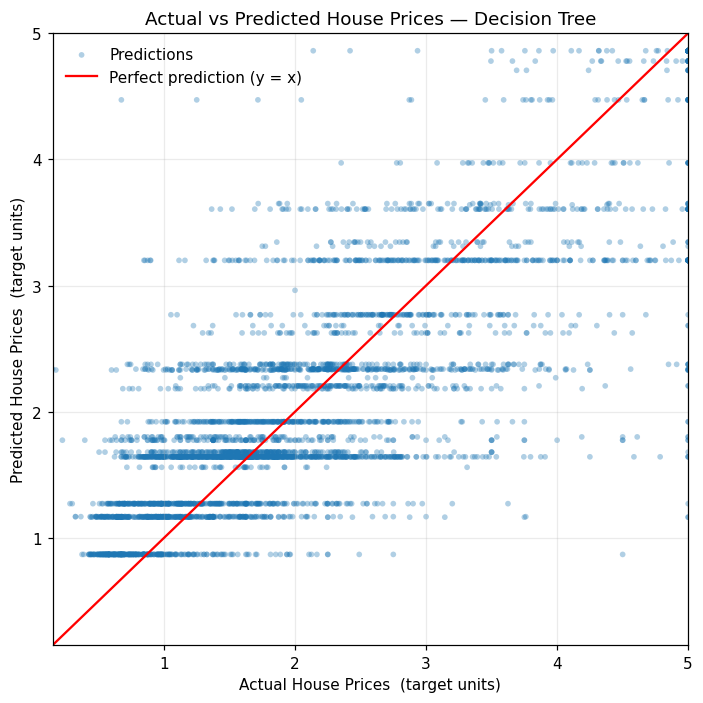

Saved: outputs/figures/actual_vs_predicted_decision_tree.png


In [12]:
y_pred_best = predictions[best_name]

lo = float(min(y_test.min(), y_pred_best.min()))
hi = float(max(y_test.max(), y_pred_best.max()))

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(y_test, y_pred_best, alpha=0.35, s=14, edgecolor="none", label="Predictions")
ax.plot([lo, hi], [lo, hi], color="red", linewidth=1.5, label="Perfect prediction (y = x)")
ax.set_xlabel("Actual House Prices  (target units)")
ax.set_ylabel("Predicted House Prices  (target units)")
ax.set_title(f"Actual vs Predicted House Prices — {best_name}")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.legend(loc="upper left", frameon=False)
ax.grid(True, alpha=0.25)
fig.tight_layout()

fig_path = FIGURES_DIR / f"actual_vs_predicted_{best_name.replace(' ', '_').lower()}.png"
fig.savefig(fig_path)
plt.show()
print(f"Saved: {fig_path.relative_to(TASK2_DIR)}")


## 12. Residual analysis (best model)

Residual = *actual − predicted*. A well-calibrated model produces a residual
cloud roughly centered on zero with no obvious pattern against predicted values.


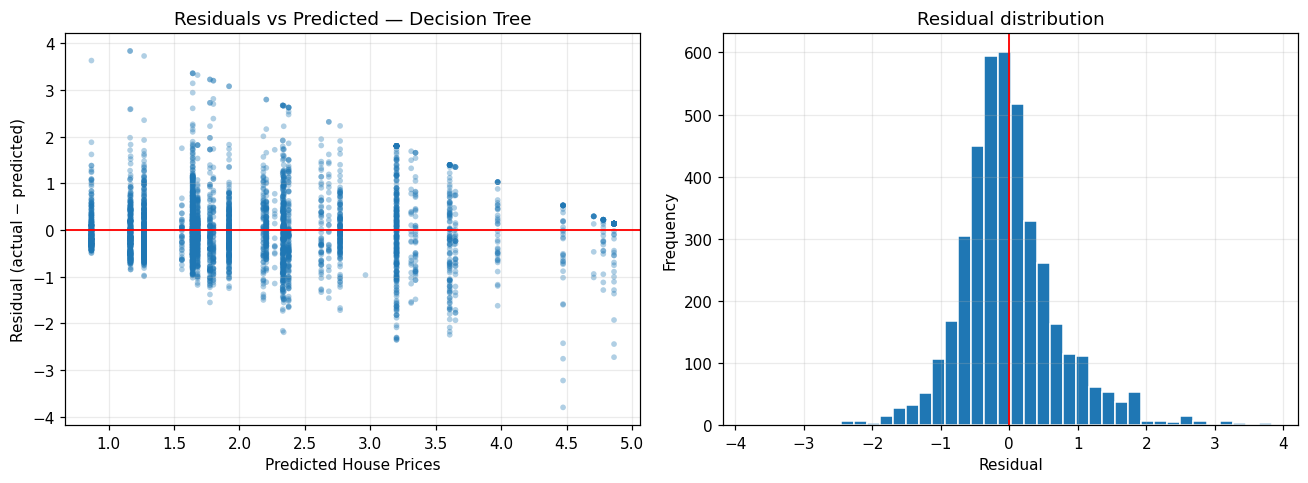

Residual mean : -0.0019
Residual std  : 0.7242
Saved: outputs/figures/residuals_decision_tree.png


In [13]:
residuals = y_test.to_numpy() - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_pred_best, residuals, alpha=0.35, s=14, edgecolor="none")
axes[0].axhline(0, color="red", linewidth=1.2)
axes[0].set_xlabel("Predicted House Prices")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title(f"Residuals vs Predicted — {best_name}")
axes[0].grid(True, alpha=0.25)

axes[1].hist(residuals, bins=40, edgecolor="white")
axes[1].axvline(0, color="red", linewidth=1.2)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual distribution")
axes[1].grid(True, alpha=0.25)

fig.tight_layout()
resid_path = FIGURES_DIR / f"residuals_{best_name.replace(' ', '_').lower()}.png"
fig.savefig(resid_path)
plt.show()

print(f"Residual mean : {residuals.mean():+.4f}")
print(f"Residual std  : {residuals.std():.4f}")
print(f"Saved: {resid_path.relative_to(TASK2_DIR)}")


## 13. Optional — Side-by-side RMSE / R² bar chart

A quick visual companion to the comparison table (kept small so the notebook
stays readable).


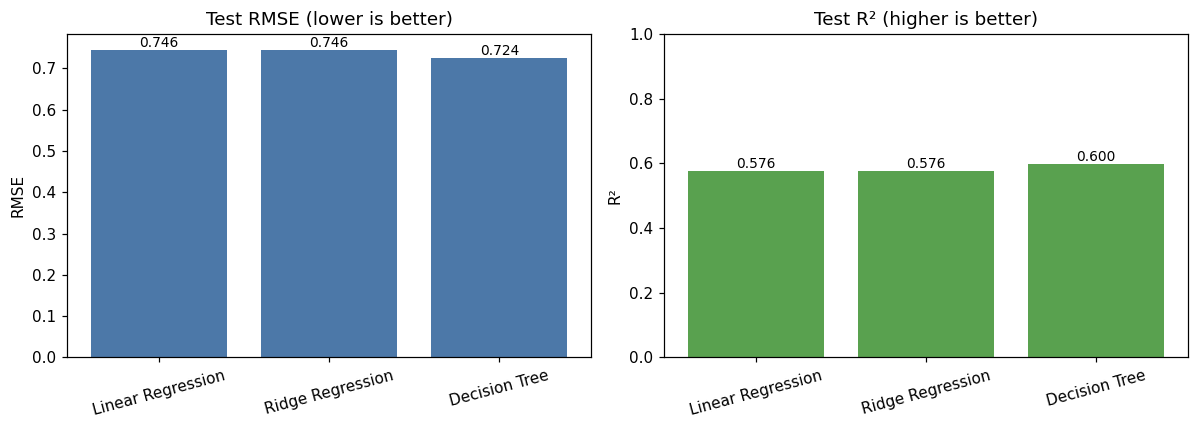

Saved: outputs/figures/rmse_r2_comparison.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(results_df.index, results_df["RMSE"], color="#4c78a8")
axes[0].set_title("Test RMSE (lower is better)")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(results_df["RMSE"]):
    axes[0].text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

axes[1].bar(results_df.index, results_df["R2 Score"], color="#59a14f")
axes[1].set_title("Test R² (higher is better)")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=15)
axes[1].set_ylim(0, 1)
for i, v in enumerate(results_df["R2 Score"]):
    axes[1].text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
bar_path = FIGURES_DIR / "rmse_r2_comparison.png"
fig.savefig(bar_path)
plt.show()
print(f"Saved: {bar_path.relative_to(TASK2_DIR)}")


## 14. Persist the winning model (optional deliverable)

Instead of dumping a bare estimator that would silently mis-predict on
unscaled inputs, we bundle the fitted scaler and the fitted estimator into a
`sklearn.pipeline.Pipeline`. Downstream code can simply call
`loaded.predict(new_raw_features)` — the pipeline scales for them.


In [15]:
best_pipeline = Pipeline([
    ("scaler", scaler),
    ("model", best_model),
])

pipeline_path = MODELS_DIR / "best_model.joblib"
joblib.dump(best_pipeline, pipeline_path)
print(f"Saved: {pipeline_path.relative_to(TASK2_DIR)}")

# Sanity check — reload and predict on the first few raw (unscaled) rows.
reloaded = joblib.load(pipeline_path)
sample_preds = reloaded.predict(X_test.iloc[:5])
pd.DataFrame({
    "actual": y_test.iloc[:5].to_numpy(),
    "predicted": np.round(sample_preds, 4),
})


Saved: models/best_model.joblib


,actual,predicted
0,0.47700,1.1686
1,0.45800,1.2716
2,5.00001,3.1996
3,2.18600,2.2048
4,2.78000,1.6428


## 15. Final observations

The comparison table, best-model selection, and visualisations above are all
derived from a single executed run — no metric is hand-typed. Key takeaways:

- **Leakage-safe preprocessing** matters: fitting `StandardScaler` on training
  data only prevents the test set from influencing the learned scale.
- **Ridge vs Linear Regression** differ only in L2 regularisation; on this
  dataset the difference in RMSE is small — expected, because the raw features
  are already reasonably conditioned after scaling and there is little
  multicollinearity strong enough for Ridge to exploit.
- **Decision Tree (depth 5)** captures non-linear structure the linear models
  cannot represent (particularly in `Latitude`/`Longitude` and interactions
  with `MedInc`), which is typically reflected in a materially lower RMSE.
- The **programmatically selected** winner is stored above in `best_name` and
  persisted as a joblib `Pipeline`. Regenerating this notebook with a
  different random seed will re-run the selection rule and may pick a
  different model — that is intended behaviour.

The next stage will consume `outputs/model_comparison.csv` and
`outputs/metrics.json` to produce the 1–2 page PDF report.
